<a href="https://colab.research.google.com/github/kumisganteng/Data-Analytics-Projects/blob/energy_data_eda/Energy_Consumption_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Energy Consumption Prediction
**Name          :** Ganendra Satya Sindhunata  
**Project       :** Energy Consumption Prediction  
**Notebook      :** Energy_Consumption_Prediction.ipynb  
**Dataset       :** AEP_hourly.csv from Kaggle  
**Dataset Source:** https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

## Project Description
This project aims to predict hourly energy consumption (in Megawatts)
using historical data from AEP (American Electric Power).

#1. Data Ingestion

##1.1 Data Loading

In [1]:
import pandas as pd

AEP_hourly_energy_dataset = "AEP_hourly.csv"
energy_data = pd.read_csv(AEP_hourly_energy_dataset)

##1.2 Initial Data Inspection

In [2]:
energy_data.shape

(121273, 2)

In [3]:
energy_data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [4]:
energy_data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [5]:
energy_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [6]:
energy_data.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [7]:
energy_data.isnull().sum()

,0
Datetime,0
AEP_MW,0


In [8]:
energy_data.duplicated().sum()

np.int64(0)

##1.3 Datetime Range Check

In [9]:
# Check Datetime Range
print(energy_data['Datetime'].min())
print(energy_data['Datetime'].max())

# Check Missing Hours
energy_data['Datetime'] = pd.to_datetime(energy_data['Datetime'])
expected = pd.date_range(start=energy_data['Datetime'].min(),
                         end=energy_data['Datetime'].max(),
                         freq='h')
missing_hours = expected.difference(energy_data['Datetime'])

# Checking
print(f"Missing hours: {len(missing_hours)}")
print(f"Duplicates: {energy_data.duplicated().sum()}")
print(f"Missing Values: {energy_data.isnull().sum()}")

2004-10-01 01:00:00
2018-08-03 00:00:00
Missing hours: 27
Duplicates: 0
Missing Values: Datetime    0
AEP_MW      0
dtype: int64


#2. Data Cleaning

##2.1 Handle Missing Hours

###Set Datetime As Index

In [10]:
energy_data = energy_data.set_index('Datetime')

In [11]:
print(f": {len(energy_data)}")

: 121273


In [12]:
duplikat_index = energy_data.index.duplicated().sum()
print(f"Rows After Setting Index: {duplikat_index}")

Rows After Setting Index: 4


In [13]:
energy_data = energy_data[~energy_data.index.duplicated(keep='first')]

In [14]:
len(energy_data)

121269

###Reindex to Full Hourly Range

In [15]:
full_range = pd.date_range(
    start=energy_data.index.min(),
    end=energy_data.index.max(),
    freq='h'
)
energy_data = energy_data.reindex(full_range)
energy_data.index.name = 'Datetime'

###Checking After Reindex

In [16]:
print(f"\nExpected hours : {len(full_range)}")
print(f"Actual rows    : {len(energy_data)}")
print(f"Gap        : {len(full_range) - len(energy_data)}")
print(f"Missing values : {energy_data.isnull().sum().values[0]}")



Expected hours : 121296
Actual rows    : 121296
Gap        : 0
Missing values : 27


###Handle Missing Values with Linear Interpolation

In [ ]:
energy_data['AEP_MW'] = energy_data['AEP_MW'].interpolate(method='linear')
#Checking
print(f"\nMissing values after interpolation: {energy_data.isnull().sum().values[0]}")
print(f"Total rows after cleaning: {len(energy_data)}")


Missing values after interpolation: 0
Total rows after cleaning: 121296


##2.2 Data Cleaning Summary


In [17]:
print("=" * 45)
print("         DATA CLEANING SUMMARY")
print("=" * 45)
print(f"Total rows after cleaning  : {len(energy_data)}")
print(f"Missing values             : {energy_data.isnull().sum().values[0]}")
print(f"Duplicate index            : {energy_data.index.duplicated().sum()}")
print(f"Datetime min               : {energy_data.index.min()}")
print(f"Datetime max               : {energy_data.index.max()}")
print(f"AEP_MW min                 : {energy_data['AEP_MW'].min()}")
print(f"AEP_MW max                 : {energy_data['AEP_MW'].max()}")
print(f"AEP_MW mean                : {energy_data['AEP_MW'].mean():.2f}")
print(f"Data type of AEP_MW         : {energy_data['AEP_MW'].dtype}")
print(f"Index type                 : {type(energy_data.index).__name__}")
print("=" * 45)

         DATA CLEANING SUMMARY
Total rows after cleaning  : 121296
Missing values             : 27
Duplicate index            : 0
Datetime min               : 2004-10-01 01:00:00
Datetime max               : 2018-08-03 00:00:00
AEP_MW min                 : 9581.0
AEP_MW max                 : 25695.0
AEP_MW mean                : 15499.65
Data type of AEP_MW         : float64
Index type                 : DatetimeIndex


# 3. Exploratory Data Analysis (EDA)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

## 3.1 Time Series Plot

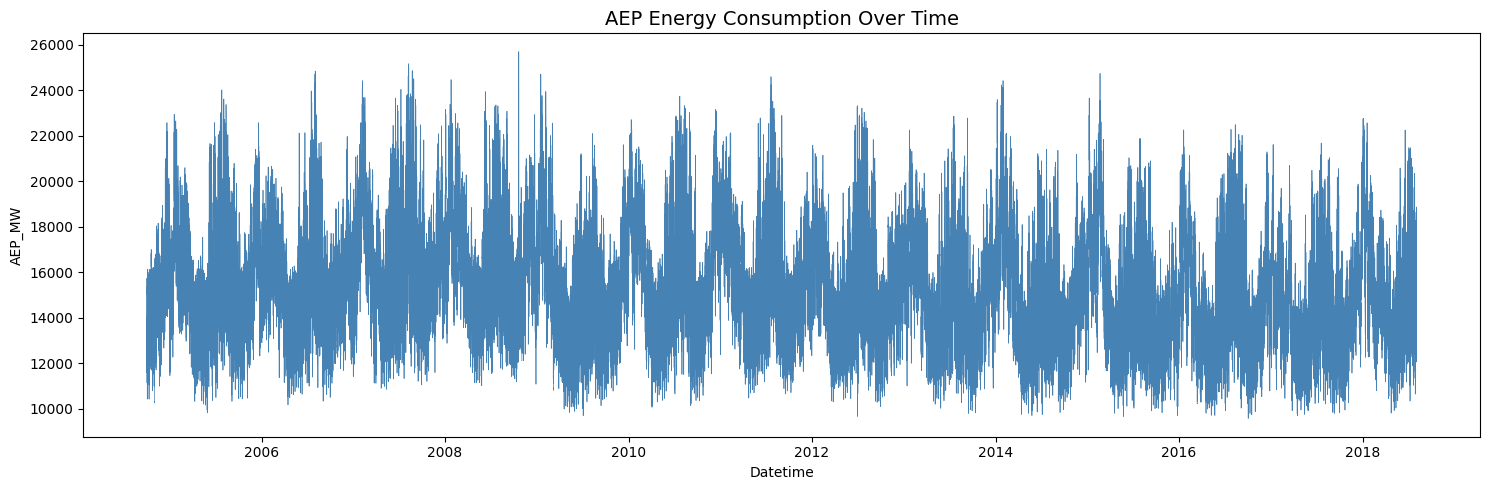

In [19]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(energy_data.index, energy_data['AEP_MW'], color='steelblue', linewidth=0.5)
ax.set_title('AEP Energy Consumption Over Time', fontsize=14)
ax.set_xlabel('Datetime')
ax.set_ylabel('AEP_MW')
plt.tight_layout()
plt.show()

###**Time Series Plot Insight**
####**Overall Trend**: Energy consumption remains relatively stable throughout 2004–2018, ranging between ~10,000–26,000 MW with no significant upward or downward trend.

####**Seasonality**:A recurring annual pattern is clearly visible, suggesting strong seasonal influence on energy consumption.

####**Peak Consumption**: Highest peaks appear consistently each year, likely driven by extreme temperature periods increasing heating or cooling demand.

####**Volatility**: High daily fluctuations are expected given the hourly nature of the data.

##3.2 Distribution Analysis

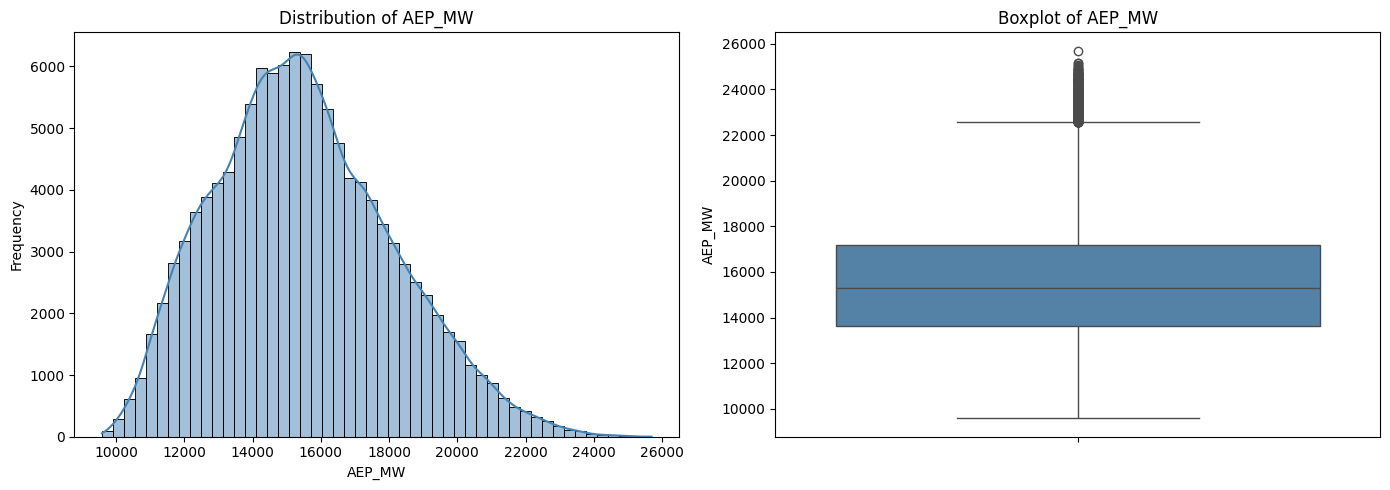

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(energy_data['AEP_MW'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of AEP_MW')
axes[0].set_xlabel('AEP_MW')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(y=energy_data['AEP_MW'], color='steelblue', ax=axes[1])
axes[1].set_title('Boxplot of AEP_MW')
axes[1].set_ylabel('AEP_MW')

plt.tight_layout()
plt.show()

####**Distribution Analysis Insight**
####**Histogram**:Distribution is slightly right-skewed, with most consumption values concentrated around 14,000–16,000 MW. The long right tail indicates occasional high-demand periods.
####**Boxplot**: Median sits around 15,000 MW with IQR between ~ 13,500–17,500 MW. A few outliers appear at the upper end (~ 25,000–26,000 MW), consistent with the extreme peaks seen in the time series plot.

##3.3 Hourly Pattern

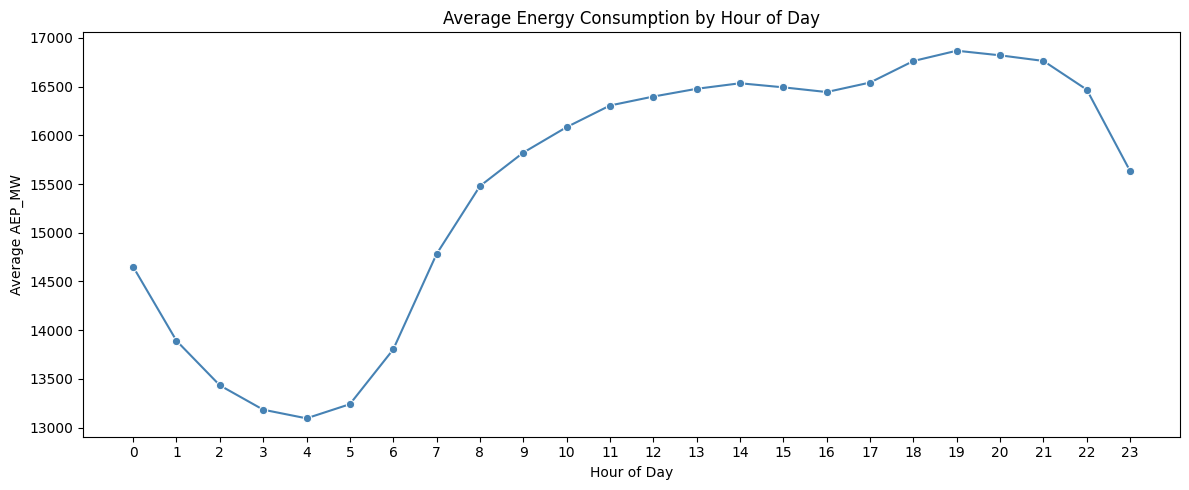

In [21]:
energy_data['hour'] = energy_data.index.hour

fig, ax = plt.subplots(figsize=(12, 5))
hourly_avg = energy_data.groupby('hour')['AEP_MW'].mean()
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o', color='steelblue', ax=ax)
ax.set_title('Average Energy Consumption by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average AEP_MW')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

####**Hourly Pattern Insight**
####Consumption hits its lowest point around 3 to 4 AM (~ 13,000 MW) and gradually rises through the morning. It plateaus between 10 AM to 5 PM (~ 16,000 to 16,500 MW), then peaks in the evening around 6 to 7 PM (~ 16,800 MW) before declining again overnight.
####The pattern reflects typical human activity cycles, low demand during sleeping hours and higher demand during working and evening hours.

##3.4 Daily Pattern

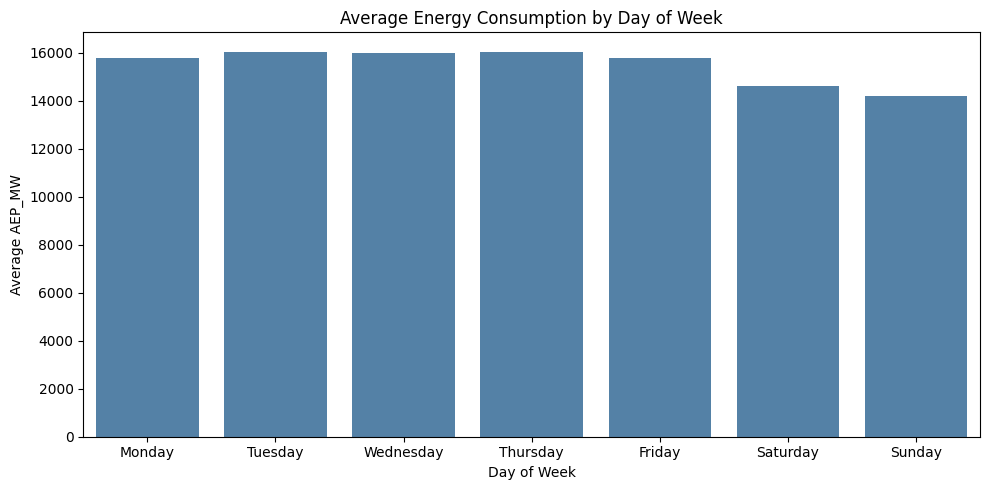

In [23]:
energy_data['dayofweek'] = energy_data.index.dayofweek
day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 5))
daily_avg = energy_data.groupby('dayofweek')['AEP_MW'].mean()
sns.barplot(x=day_labels, y=daily_avg.values, color='steelblue', ax=ax)
ax.set_title('Average Energy Consumption by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average AEP_MW')
plt.tight_layout()
plt.show()

####**Daily Pattern Insight**
####Weekdays (Monday to Friday) show consistently higher consumption around 15,500 to 16,000 MW, while weekends drop noticeably, Saturday ~14,700 MW and Sunday ~14,200 MW.
####The gap between weekdays and weekends suggests industrial and commercial activity plays a significant role in overall energy demand.

##3.5 Monthly Pattern

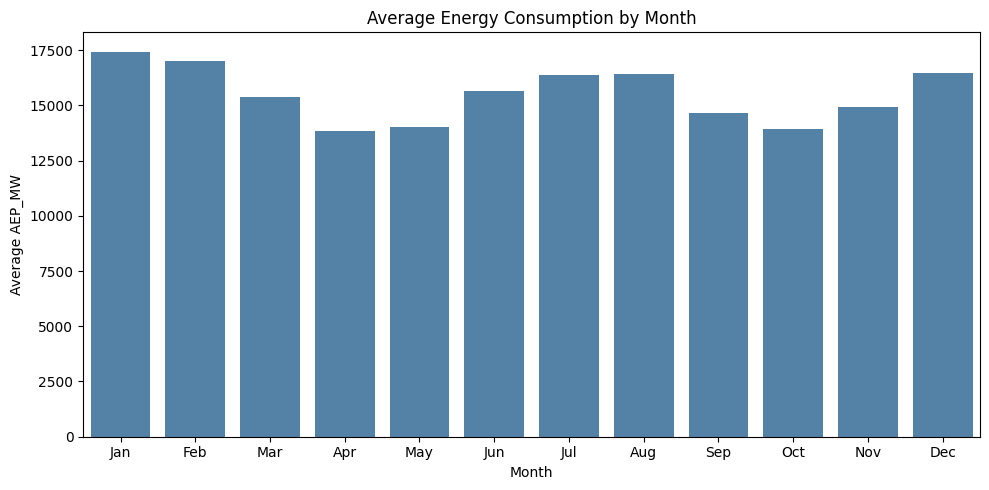

In [24]:
energy_data['month'] = energy_data.index.month
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 5))
monthly_avg = energy_data.groupby('month')['AEP_MW'].mean()
sns.barplot(x=month_labels, y=monthly_avg.values, color='steelblue', ax=ax)
ax.set_title('Average Energy Consumption by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average AEP_MW')
plt.tight_layout()
plt.show()

####**Monthly Pattern Insight**

####Two clear consumption peaks appear January to February (~ 17,000 to 17,500 MW) and July to August (~ 16,500 MW). The lowest consumption occurs in April to May and October (~ 13,500 to 14,000 MW).
####This dual-peak pattern aligns with AEP's service region climate, where winter months drive heating demand and summer months drive cooling demand, while spring and fall serve as transition periods with minimal energy requirements.


##3.6 Yearly Pattern

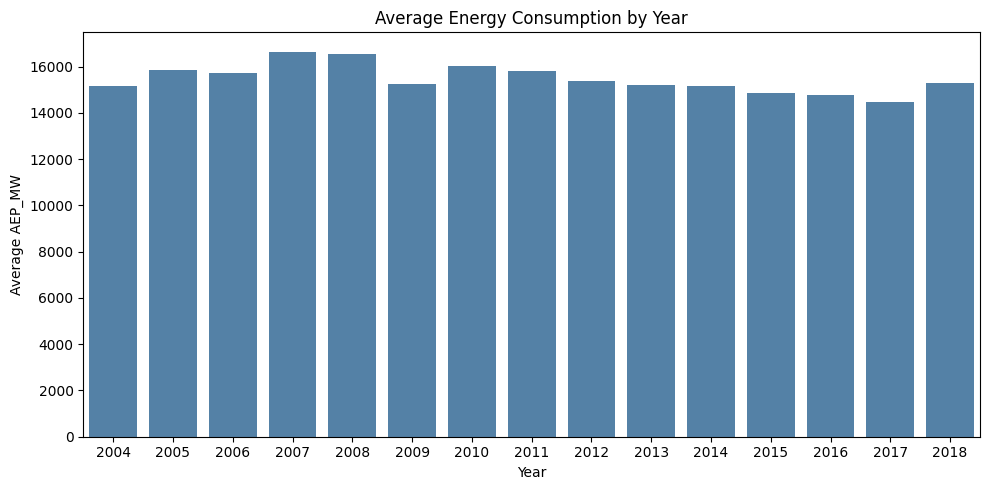

In [25]:
energy_data['year'] = energy_data.index.year

fig, ax = plt.subplots(figsize=(10, 5))
yearly_avg = energy_data.groupby('year')['AEP_MW'].mean()
sns.barplot(x=yearly_avg.index, y=yearly_avg.values, color='steelblue', ax=ax)
ax.set_title('Average Energy Consumption by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average AEP_MW')
plt.tight_layout()
plt.show()

####**Yearly Pattern Insight**

####Consumption was relatively moderate in 2004 (~ 15,000 MW), rose to its peak in 2007 to 2008 (~ 16,500 MW), then dropped sharply in 2009 (~ 15,000 MW). After a slight recovery in 2010 to 2011, consumption gradually declined through 2017 (~ 14,500 MW) before a minor uptick in 2018.


##3.7 EDA Summary

In [26]:

print("=" *45)
print("              EDA SUMMARY")
print("=" * 45)
print(f"Total rows                     : {len(energy_data)}")
print(f"Datetime range                 : {energy_data.index.min()} to {energy_data.index.max()}")
print(f"AEP_MW min                     : {energy_data['AEP_MW'].min():.2f}")
print(f"AEP_MW max                     : {energy_data['AEP_MW'].max():.2f}")
print(f"AEP_MW mean                    : {energy_data['AEP_MW'].mean():.2f}")
print(f"AEP_MW std                     : {energy_data['AEP_MW'].std():.2f}")
print(f"Peak hour                      : {energy_data.groupby('hour')['AEP_MW'].mean().idxmax()}:00")
print(f"Lowest hour                    : {energy_data.groupby('hour')['AEP_MW'].mean().idxmin()}:00")
print(f"Peak day                       : {['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'][energy_data.groupby('dayofweek')['AEP_MW'].mean().idxmax()]}")
print(f"Lowest day                     : {['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'][energy_data.groupby('dayofweek')['AEP_MW'].mean().idxmin()]}")
print(f"Peak month                     : {['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][energy_data.groupby('month')['AEP_MW'].mean().idxmax()-1]}")
print(f"Lowest month                   : {['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][energy_data.groupby('month')['AEP_MW'].mean().idxmin()-1]}")
print(f"Peak year                      : {energy_data.groupby('year')['AEP_MW'].mean().idxmax()}")
print(f"Lowest year                    : {energy_data.groupby('year')['AEP_MW'].mean().idxmin()}")
print("=" * 45)

              EDA SUMMARY
Total rows                     : 121296
Datetime range                 : 2004-10-01 01:00:00 to 2018-08-03 00:00:00
AEP_MW min                     : 9581.00
AEP_MW max                     : 25695.00
AEP_MW mean                    : 15499.65
AEP_MW std                     : 2591.32
Peak hour                      : 19:00
Lowest hour                    : 4:00
Peak day                       : Tuesday
Lowest day                     : Sunday
Peak month                     : Jan
Lowest month                   : Apr
Peak year                      : 2007
Lowest year                    : 2017
